In [1]:
# Goal:
# Explore booking patterns in Bethpage tee time reservations
# to understand demand patterns and identify capacity bottlenecks.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_parquet("../data/cleaned/bethpage_bookings_clean.parquet")
display(df.head())
display(df.size)
display(df.columns)




,tee_time,booking_time,status_text,date_cancelled,time_of_week,time_of_day,player_count_final,course,round_length,cost_per_group,invalid_cancellation,invalid_tee_time
0,2021-03-14 07:51:00,2021-03-07 19:00:00,played,NaT,weekend,morning,2,Blue,9,124.0,False,False
1,2021-03-14 07:51:00,2021-03-13 21:35:00,played,NaT,weekend,morning,1,Blue,9,31.0,False,False
2,2021-03-14 08:00:00,2021-03-13 15:32:00,played,NaT,weekend,morning,2,Blue,9,62.0,False,False
3,2021-03-14 08:27:00,2021-03-13 11:19:00,played,NaT,weekend,morning,4,Blue,9,124.0,False,False
4,2021-03-14 08:36:00,2021-03-13 17:42:00,played,NaT,weekend,morning,3,Blue,9,93.0,False,False


7392156

Index(['tee_time', 'booking_time', 'status_text', 'date_cancelled',
       'time_of_week', 'time_of_day', 'player_count_final', 'course',
       'round_length', 'cost_per_group', 'invalid_cancellation',
       'invalid_tee_time'],
      dtype='object')

In [2]:
#basic data review & integrity checks
display(df.info())
display(df.describe())
display(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616013 entries, 0 to 616012
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tee_time              616013 non-null  datetime64[ns]
 1   booking_time          616013 non-null  datetime64[ns]
 2   status_text           616013 non-null  category      
 3   date_cancelled        308209 non-null  datetime64[ns]
 4   time_of_week          616013 non-null  category      
 5   time_of_day           616013 non-null  category      
 6   player_count_final    616013 non-null  int64         
 7   course                616013 non-null  object        
 8   round_length          616013 non-null  int64         
 9   cost_per_group        599873 non-null  float64       
 10  invalid_cancellation  616013 non-null  bool          
 11  invalid_tee_time      616013 non-null  bool          
dtypes: bool(2), category(3), datetime64[ns](3), float64(1), in

None

,tee_time,booking_time,date_cancelled,player_count_final,round_length,cost_per_group
count,616013,616013,308209,616013.000000,616013.000000,599873.000000
mean,2023-07-01 22:32:30.253387008,2023-06-28 14:58:39.553970176,2023-08-13 06:57:42.089835008,2.620841,15.286426,121.420126
min,2021-03-14 07:51:00,2021-03-07 19:00:00,2021-03-11 14:44:21,1.000000,9.000000,0.000000
25%,2022-07-24 11:27:00,2022-07-21 12:57:00,2022-09-29 11:47:00,1.000000,9.000000,53.000000
50%,2023-07-08 17:36:00,2023-07-05 19:00:00,2023-07-28 12:51:00,2.000000,18.000000,106.000000
75%,2024-06-16 14:30:00,2024-06-13 14:00:00,2024-05-28 19:28:01,4.000000,18.000000,172.000000
max,2025-10-21 14:00:00,2025-10-15 14:44:00,2025-10-15 13:40:01,4.000000,18.000000,660.000000
std,NaN,NaN,NaN,1.287341,4.130219,80.425605


tee_time                     0
booking_time                 0
status_text                  0
date_cancelled          307804
time_of_week                 0
time_of_day                  0
player_count_final           0
course                       0
round_length                 0
cost_per_group           16140
invalid_cancellation         0
invalid_tee_time             0
dtype: int64

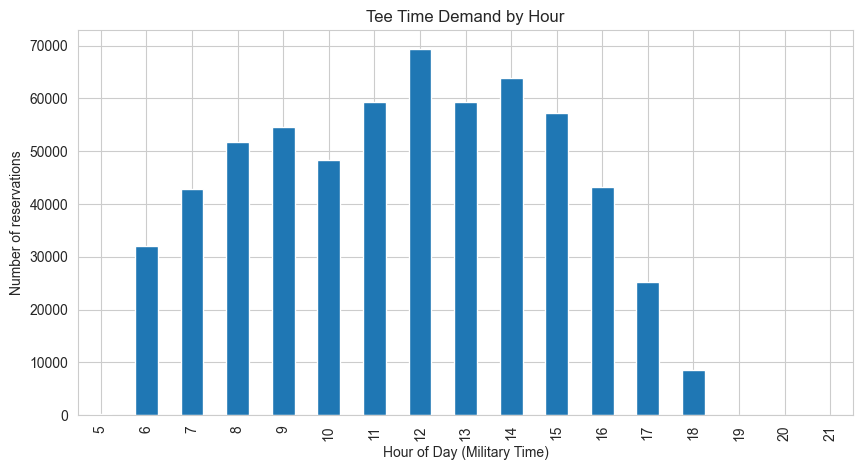

In [3]:
#demand by hour
hourly_demand = df.groupby(df["tee_time"].dt.hour).size()

hourly_demand.plot(kind="bar",figsize=(10,5))
plt.title("Tee Time Demand by Hour")
plt.xlabel("Hour of Day (Military Time)")
plt.ylabel("Number of reservations")
plt.show()

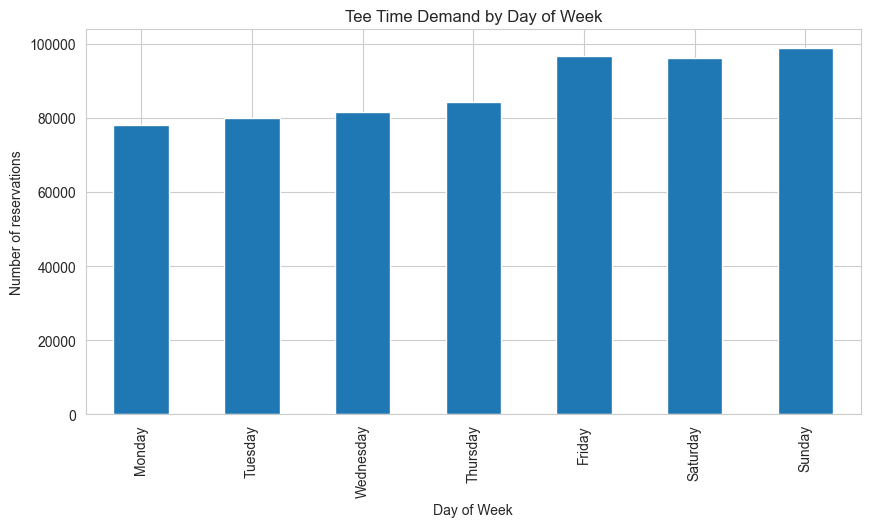

In [4]:
#demand by day of week 
DOW_demand = df.groupby(df["tee_time"].dt.day_name()).size()
day_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]
DOW_demand = DOW_demand.reindex(day_order)

DOW_demand.plot(kind="bar",figsize=(10,5))
plt.title("Tee Time Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of reservations")
plt.show()


,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
tee_time,,,,,,,
5,57.0,37.0,33.0,23.0,50.0,37.0,28.0
6,5558.0,4898.0,3904.0,4617.0,4730.0,4176.0,4184.0
7,6830.0,6082.0,4867.0,5971.0,6170.0,6348.0,6536.0
8,7569.0,6874.0,6312.0,6951.0,7542.0,8108.0,8383.0
9,7764.0,6686.0,7135.0,7511.0,7434.0,8694.0,9398.0
10,6492.0,5807.0,6598.0,6453.0,7721.0,7381.0,7843.0
11,7629.0,7284.0,8272.0,8369.0,9564.0,9264.0,8993.0
12,9067.0,9086.0,9444.0,9527.0,10669.0,10669.0,10963.0
13,6786.0,8466.0,8817.0,8747.0,9172.0,8341.0,8994.0


Index(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'],
      dtype='object')

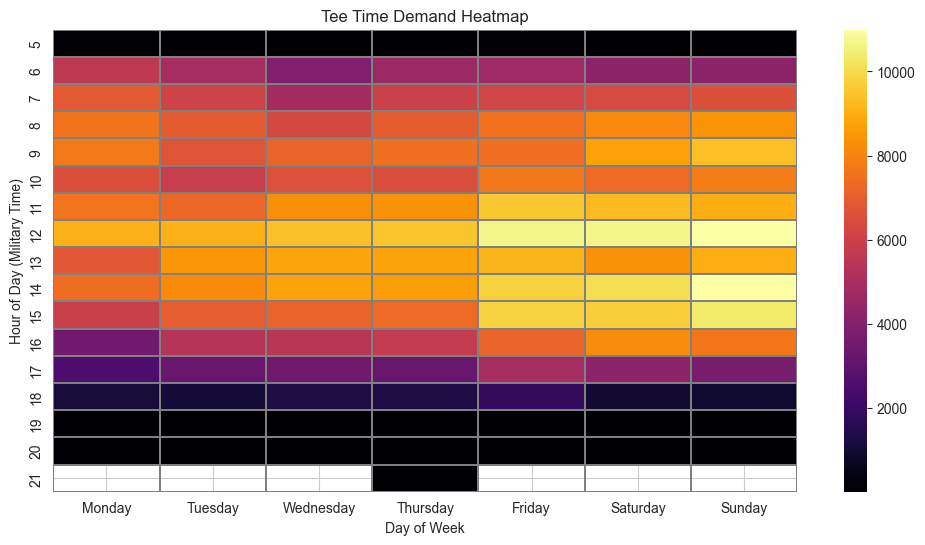

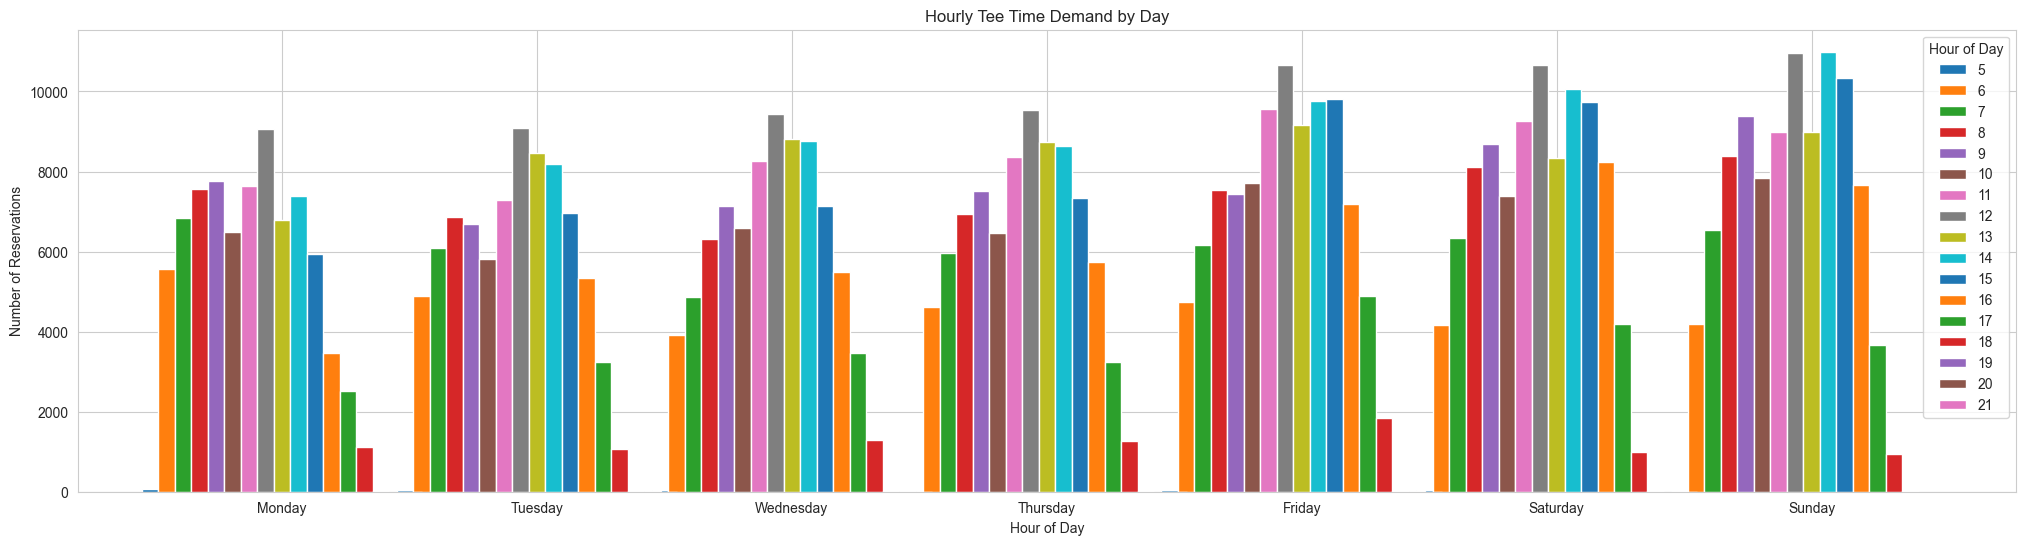

In [5]:
#DOW vs Hour heatmap
heatmap_data = df.groupby([df["tee_time"].dt.hour,df["tee_time"].dt.dayofweek]).size().unstack()
heatmap_data.columns = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]
display(heatmap_data)
display(heatmap_data.columns)

#heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("Tee Time Demand Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Day of Week")
plt.show()

#day by hour bar chart
heatmap_data.T.plot(kind="bar",figsize=(25,6),width=1.1)
plt.title("Hourly Tee Time Demand by Day")
plt.legend(title="Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Reservations")
plt.xticks(rotation=0)
plt.show()

,tee_time,booking_time,status_text,date_cancelled,time_of_week,time_of_day,player_count_final,course,round_length,cost_per_group,invalid_cancellation,invalid_tee_time
5358,2021-04-16 05:18:00,2021-04-15 18:26:00,unknown,NaT,weekday,morning,4,Yellow,9,172.0,False,False
11572,2021-05-10 05:45:00,2021-05-03 19:30:00,played,NaT,weekday,morning,1,Yellow,9,28.0,False,False
12408,2021-05-13 05:54:00,2021-05-12 21:52:00,played,NaT,weekday,morning,1,Red,18,28.0,False,False
13612,2021-05-16 05:45:00,2021-05-15 22:01:00,played,NaT,weekend,morning,1,Yellow,9,31.0,False,False
14007,2021-05-17 05:45:00,2021-05-16 16:39:00,played,NaT,weekday,morning,1,Red,18,48.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
607872,2025-08-01 05:54:00,2025-07-25 19:03:00,cancelled,2025-08-01 07:09:53,weekday,morning,4,Blue,18,100.0,False,False
608128,2025-08-02 05:54:00,2025-07-26 19:11:00,played,NaT,weekend,morning,1,Yellow,9,NaN,False,False
608384,2025-08-03 05:54:00,2025-07-27 19:00:00,played,NaT,weekend,morning,1,Yellow,9,0.0,False,False
615312,2025-10-13 05:00:00,2025-10-06 19:00:00,cancelled,2025-10-15 09:53:17,weekday,morning,4,Blue,18,172.0,False,False


tee_time
2021    55
2022    46
2023    47
2024    53
2025    64
dtype: int64

tee_time,1,2,3,4,5,6,7,8,9,10,11,12
tee_time,,,,,,,,,,,,
5,8.0,3.0,2.0,6.0,71.0,86.0,57.0,7.0,2.0,3.0,11.0,9.0
6,NaN,NaN,NaN,1883.0,8150.0,9073.0,8464.0,3871.0,626.0,NaN,NaN,NaN
7,NaN,NaN,616.0,7731.0,6809.0,6623.0,6309.0,7397.0,4660.0,2172.0,479.0,8.0
8,2.0,NaN,2614.0,8475.0,5985.0,5388.0,5618.0,4891.0,4970.0,7597.0,6121.0,78.0
9,572.0,699.0,2829.0,6602.0,7488.0,6783.0,6942.0,5693.0,4225.0,4943.0,7022.0,824.0
10,1456.0,1569.0,2385.0,6180.0,5552.0,5492.0,5558.0,4989.0,4751.0,4594.0,4194.0,1575.0
11,1271.0,1231.0,2686.0,7446.0,7443.0,6851.0,6599.0,5977.0,5335.0,6250.0,6706.0,1580.0
12,1724.0,1767.0,3218.0,8377.0,8427.0,7744.0,7681.0,7406.0,6362.0,7222.0,7202.0,2295.0
13,1100.0,1875.0,2876.0,6613.0,7527.0,6984.0,7028.0,6226.0,5362.0,7087.0,5331.0,1314.0


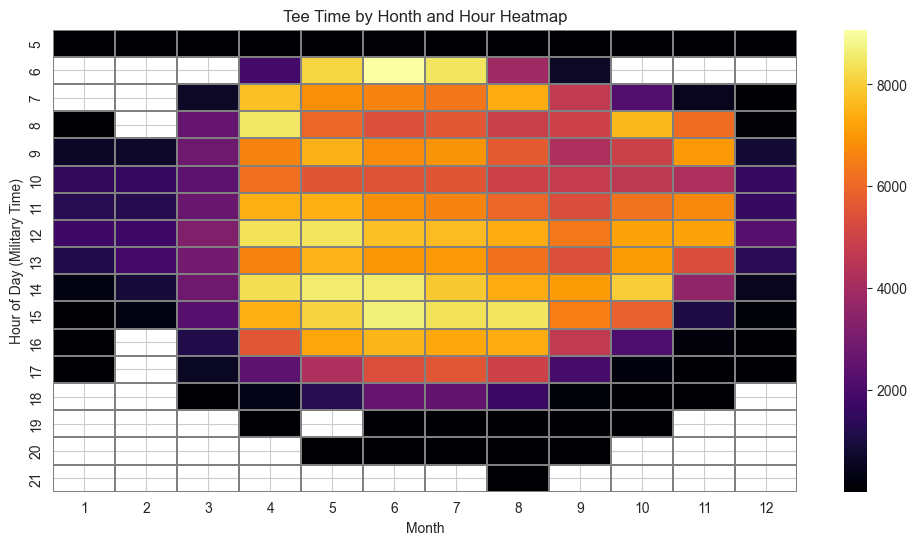

In [13]:
#check odd lack of 5am hour tee times
five_am_res = df[df["tee_time"].dt.hour == 5]
display(five_am_res)
display(five_am_res.groupby(five_am_res["tee_time"].dt.year).size())
#5am times do exist they are just relatively rare, likely due to not being available year round (dst, short spring and fall days)
#also likely undesireable to NYC residents as it takes over an hour to reach the course by car or train

#heatmap of month/hour to confirm daylight restriction theory
early_tee_time_heatmap_data = df.groupby([df["tee_time"].dt.hour,df['tee_time'].dt.month]).size().unstack()
display(early_tee_time_heatmap_data)
plt.figure(figsize=(12,6))
sns.heatmap(early_tee_time_heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("Tee Time by Honth and Hour Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Month")
plt.show()